In [ ]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from functools import wraps
import time
from numba import jit


def timeit(func):
    @wraps(func)
    def timeit_wrapper(*args, **kwargs):
        start_time = time.perf_counter()
        result = func(*args, **kwargs)
        end_time = time.perf_counter()
        total_time = end_time - start_time
        print(f"Function {func.__name__} took {total_time:.4f} seconds")
        return result

    return timeit_wrapper


def compute_K_integrals(x, r, sigma, beta=1):
    def K1_integrand(y):
        return np.exp(-(y**2) * (beta * r + beta * x) / sigma**2)

    def K2_integrand(y):
        return np.exp(
            -(y**2) * (4 * beta * r - beta * x) / (4 * sigma**2)
            + y**3 * (5 * beta * x) / (3 * sigma**2)
        )

    def K3_integrand(y):
        return np.exp((20 * y**3 * beta * r) / (3 * sigma**2))

    K1, _ = quad(K1_integrand, -np.inf, -0.5, epsabs=1e-30, epsrel=1e-11)
    K2, _ = quad(K2_integrand, -0.5, -0.1, epsabs=1e-30, epsrel=1e-11)
    K3, _ = quad(K3_integrand, -0.1, 0.0, epsabs=1e-30, epsrel=1e-11)

    return K1, K2, K3


def calculate_probabilities(r, x, sigma):
    """
    Calculate the probabilities p_1,...,p_6 as a function of r, x, and sigma.

    Parameters:
    r (float): Capacity reserved for FCR-N.
    x (float): Decision variable, capacity reserved for FCR-D.
    sigma (float): Volatility.

    Returns:
    dict: A dictionary with the probabilities p_1, p_2, p_3 (and p_4, p_5, p_6 since p_4 = p_3, p_5 = p_2, p_6 = p_1).
    """
    K1, K2, K3 = compute_K_integrals(x, r, sigma)

    exp1 = np.exp(-5 * x / (48 * sigma**2))
    exp2 = np.exp(-(31 * x + r) / (300 * sigma**2))

    if K1 == 0 or np.log10(K1) < -15:
        denom = 2 * K2 * exp1 + 2 * K3 * exp2
        p_1 = p_6 = 0.0
        p_2 = p_5 = K2 * exp1 / denom
        p_3 = p_4 = K3 * exp2 / denom
    else:
        denom = 2 + 2 * (K2 / K1) * exp1 + 2 * (K3 / K1) * exp2
        p_1 = p_6 = 1 / denom
        p_2 = p_5 = (K2 / K1) * exp1 / denom
        p_3 = p_4 = (K3 / K1) * exp2 / denom

    print(
        f"p_1: {round(p_1, 10)}\np_2: {round(p_2, 10)}\np_3: {round(p_3, 10)}\np_4: {round(p_4, 10)}\np_5: {round(p_5, 10)}\np_6: {round(p_6, 10)}"
    )

    return {
        "p_1": p_1,
        "p_2": p_2,
        "p_3": p_3,
        "p_4": p_4,
        "p_5": p_5,
        "p_6": p_6,
    }


@jit
def alpha(Ft, r=0.6, x=1.4, mu=0.0):
    """Calculate the state-dependent drift function based on the given piecewise function.

    Parameters:
    - Ft: Current value of the process.
    - r: Parameter for the drift function due to the FCR-N capacity.
    - x: Parameter for the drift function due to the FCR-D capacity.
    - mu: Long-term mean of the process.

    Returns:
    - F: The drift value based on the piecewise function.
    """
    F = Ft - mu
    if F < -0.5 or F > 0.5:
        return r + x
    elif -0.5 <= F <= -0.1:
        return r - 0.25 * x - 2.5 * x * F
    elif -0.1 < F <= 0.0:
        return -10 * r * F
    elif 0.0 < F <= 0.1:
        return 10 * r * F
    elif 0.1 < F <= 0.5:
        return r - 0.25 * x + 2.5 * x * F
    else:
        raise ValueError("F(t) is out of the expected range")


@timeit
@jit
def simulate_frequency_process(
    t_end=10, dt=0.01, sigma=0.04, F0=0, mu=0, r=0.6, x=1.4, seed=None
):
    """
    Simulates an Ornstein-Uhlenbeck process with state-dependent drift and optional random seed.

    Parameters:
    - t_end: End time of the simulation.
    - dt: Time step for the simulation.
    - sigma: Volatility parameter.
    - F0: Initial value of the process.
    - mu: Long-term mean of the process.
    - seed: Random seed for reproducibility.

    Returns:
    - F: Simulated OU process.
    """
    # Set a random seed if not provided
    if seed is not None:
        np.random.seed(seed)

    # Initialize parameters
    n_total = int(t_end / dt)  # Total number of steps
    F = np.zeros(n_total)  # Preallocate array for F
    F[0] = F0  # Start at F0
    t = np.linspace(0, t_end, n_total)  # Time points

    # Generate Brownian motion increments
    dW = np.random.normal(0, np.sqrt(dt), n_total - 1)

    for i in range(1, n_total):
        # Use state-dependent drift function (as a function of F[i-1])
        drift = alpha(F[i - 1], r, x, mu)

        # Ornstein-Uhlenbeck update with state-dependent drift
        F[i] = F[i - 1] - drift * (F[i - 1] - mu) * dt + sigma * dW[i - 1]

    return t, F


def extract_prob_intervals(F, intervals):
    """
    Extracts the probabilities of the simulated OU process being in given intervals.
    This function counts the number of samples in each interval and normalizes by the total number of samples.

    Parameters:
    - F: Simulated OU process.
    - intervals: List of tuples defining the intervals.

    Returns:
    - frequencies: List of probabilities to be in each interval.
    """
    frequencies = []
    for lower, upper in intervals:
        count = np.sum((F >= lower) & (F < upper))
        frequencies.append(count / len(F))  # Normalize by the total number of samples
    return frequencies

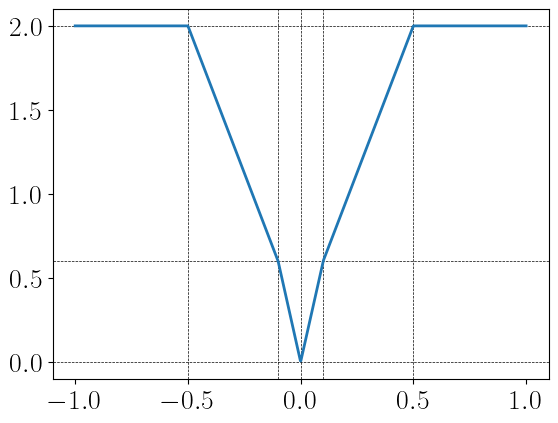

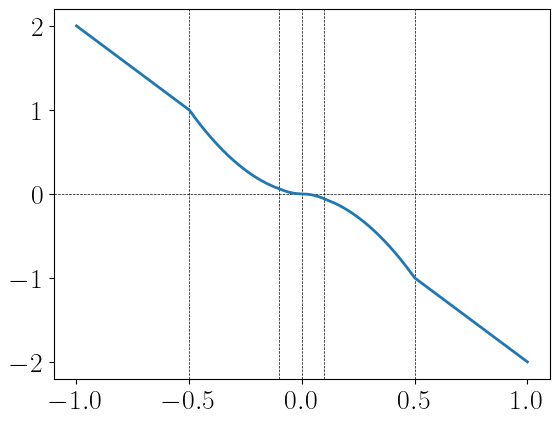

In [16]:
# Plot drift function
freq = np.linspace(-1, 1, 1000)
drift = [alpha(f) for f in freq]
plt.axhline(0, color="black", lw=0.5, ls="--")
plt.axhline(0.6, color="black", lw=0.5, ls="--")
plt.axhline(2.0, color="black", lw=0.5, ls="--")
plt.axvline(0, color="black", lw=0.5, ls="--")
plt.axvline(0.5, color="black", lw=0.5, ls="--")
plt.axvline(0.1, color="black", lw=0.5, ls="--")
plt.axvline(-0.1, color="black", lw=0.5, ls="--")
plt.axvline(-0.5, color="black", lw=0.5, ls="--")
plt.plot(freq, drift, lw=2)
plt.show()

# Plot the drift term -alpha*F from -1 to 1
freq = np.linspace(-1, 1, 1000)
drift_term = [-alpha(f) * f for f in freq]
plt.axhline(0, color="black", lw=0.5, ls="--")
plt.axvline(0, color="black", lw=0.5, ls="--")
plt.axvline(0.5, color="black", lw=0.5, ls="--")
plt.axvline(0.1, color="black", lw=0.5, ls="--")
plt.axvline(-0.1, color="black", lw=0.5, ls="--")
plt.axvline(-0.5, color="black", lw=0.5, ls="--")
plt.plot(freq, drift_term, lw=2)
plt.show()

In [15]:
t_end = 2000000  # End time
dt = 0.01  # Time step
F0 = 0.0  # Initial condition
mu = 0.0  # Long-term mean
r = 0.6  # Capacity reserved for FCR-N
x = 1.4  # Capacity reserved for FCR-D
sigma = 0.04  # Volatility
seed = 0  # Random seed for reproducibility

# Simulate the process with a seed for reproducibility
t, F = simulate_frequency_process(
    t_end=t_end, dt=dt, sigma=sigma, F0=F0, mu=mu, r=r, x=x, seed=seed
)

print("\nTheoretical probabilities:")
calculate_probabilities(r, x, sigma)

print("\nSimulated probabilities:")
intervals = [
    (-1, -0.5),
    (-0.5, -0.1),
    (-0.1, 0),
    (0, 0.1),
    (0.1, 0.5),
    (0.5, 1),
]

frequencies = extract_prob_intervals(F, intervals)

for i, ((lower, upper), freq) in enumerate(zip(intervals, frequencies)):
    print(f"p_{i+1}: {freq}")

Function simulate_frequency_process took 5.1738 seconds

Theoretical probabilities:
p_1: 0.0
p_2: 0.0070996806
p_3: 0.4929003194
p_4: 0.4929003194
p_5: 0.0070996806
p_6: 0.0

Simulated probabilities:
p_1: 0.0
p_2: 0.007139735
p_3: 0.492848055
p_4: 0.492734485
p_5: 0.007277725
p_6: 0.0


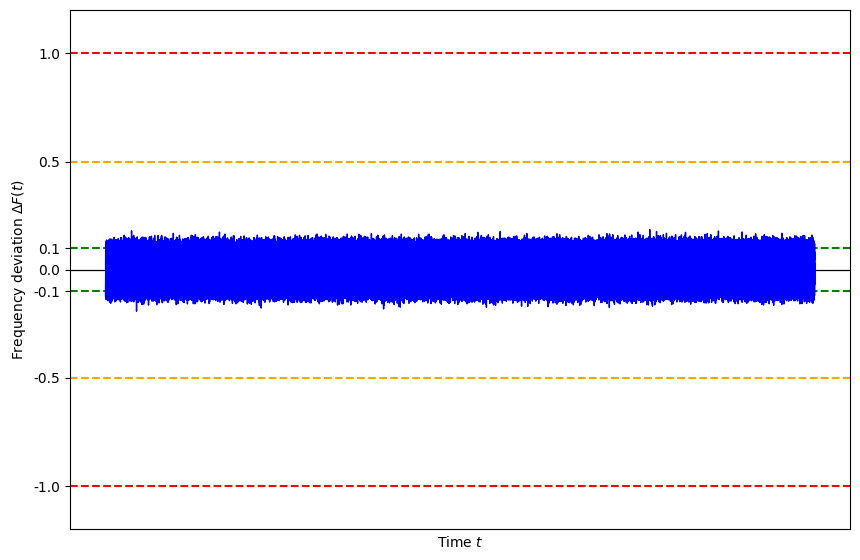

In [9]:
# Plotting settings
fig, ax = plt.subplots(figsize=(9, 6))
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20  # changes font size
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",  # optional, for better math support
    }
)
ax.set_ylim(min(np.min(F) - 0.05, -1.2), max(np.max(F) + 0.05, 1.2))
(line,) = ax.plot([], [], lw=1.5)
ax.set_xticklabels([])
ax.set_xticks([])

horizontal_lines = [-1, -0.5, -0.1, 0, 0.1, 0.5, 1]
colors = ["red", "orange", "green", "black", "green", "orange", "red"]
for y, color in zip(horizontal_lines, colors):
    if y == 0:
        ax.axhline(y=y, color=color, linestyle="-", linewidth=0.9)
    else:
        ax.axhline(y=y, color=color, linestyle="--")
ax.set_yticks(horizontal_lines)
ax.set_yticklabels([f"{y:.1f}" for y in horizontal_lines])
ax.set_xlabel("Time $t$")
ax.set_ylabel("Frequency deviation $\\Delta F(t)$")

ax.plot(t, F, color="blue", alpha=1, linewidth=1)
plt.tight_layout()
plt.show()

# Save the plot
# plt.savefig(
#     "ou_simulation.eps",
#     dpi=400,
#     bbox_inches="tight",
#     transparent=True,
# )